Linear Embeddings

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

In [2]:
val=torch.tensor([0,1,2,3,4,5,6,7,8,9])

In [3]:
labs=torch.tensor([0,1,0,1,0,1,0,1,0,1])

In [4]:
embed=nn.Embedding(10,3)
classi=nn.Linear(3,2)

In [5]:
optim=torch.optim.SGD(list(embed.parameters())+list(classi.parameters()),lr=0.1)
loss=nn.CrossEntropyLoss()

In [6]:
for ep in range(750):
    optim.zero_grad()
    vec=embed(val)
    logits=classi(vec)
    losss=loss(logits,labs)
    losss.backward()
    optim.step()

In [7]:
with torch.no_grad():
    W=embed.weight.clone()

In [8]:
W

tensor([[-0.0031, -1.4113, -0.7696],
        [ 0.9421,  0.6623,  0.6589],
        [ 0.5852, -0.7730, -2.1814],
        [ 1.0214,  0.6449,  0.5260],
        [-0.6591, -0.4014, -1.6614],
        [-1.4629,  1.3244,  1.8179],
        [-0.5610, -1.2031, -0.8765],
        [-0.4968,  0.1000,  1.0954],
        [-0.7819, -1.9775, -0.1874],
        [-2.2367,  0.5885,  0.6517]])

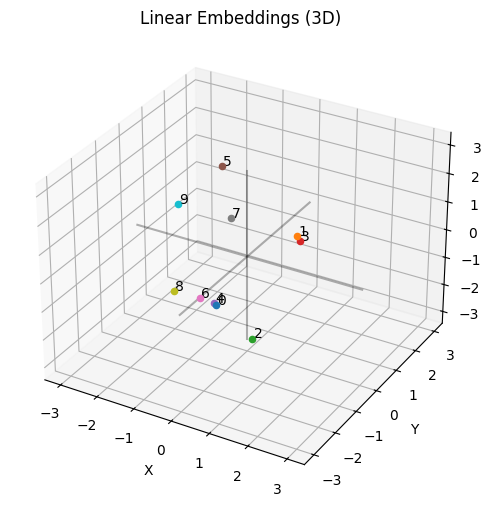

In [9]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
for i in range(10):
    x, y, z = W[i]
    ax.scatter(x, y, z)
    ax.text(x + 0.02, y + 0.02, z + 0.02, str(i))
axis_range = np.array([-3, 3]) 
ax.plot(axis_range, [0, 0], [0, 0], color='black', alpha=0.3) # X-axis
ax.plot([0, 0], axis_range, [0, 0], color='black', alpha=0.3) # Y-axis
ax.plot([0, 0], [0, 0], axis_range, color='black', alpha=0.3) # Z-axis

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Linear Embeddings (3D)')

plt.show()

Sinusoidal Embeddings

In [10]:
import torch
import torch.nn as nn
import math

In [11]:
class SinEmbe(nn.Module):
    def __init__(self,dim):
        super().__init__()
        assert dim%2==0
        self.dim=dim
    def forward(self,pos):
        half=self.dim//2
        dev=pos.device
        frq=torch.exp(-math.log(10000)*torch.arange(half,device=dev)/half)
        ang=pos.unsqueeze(1)*frq.unsqueeze(0)
        emb=torch.cat([torch.sin(ang),torch.cos(ang)],dim=1)
        return emb

In [12]:
pose=SinEmbe(dim=16)
posi=torch.arange(0,42)
embedd=pose(posi)

In [13]:
embedd

tensor([[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
          0.0000e+00,  0.0000e+00,  0.0000e+00,  1.0000e+00,  1.0000e+00,
          1.0000e+00,  1.0000e+00,  1.0000e+00,  1.0000e+00,  1.0000e+00,
          1.0000e+00],
        [ 8.4147e-01,  3.1098e-01,  9.9833e-02,  3.1618e-02,  9.9998e-03,
          3.1623e-03,  1.0000e-03,  3.1623e-04,  5.4030e-01,  9.5042e-01,
          9.9500e-01,  9.9950e-01,  9.9995e-01,  9.9999e-01,  1.0000e+00,
          1.0000e+00],
        [ 9.0930e-01,  5.9113e-01,  1.9867e-01,  6.3203e-02,  1.9999e-02,
          6.3245e-03,  2.0000e-03,  6.3246e-04, -4.1615e-01,  8.0658e-01,
          9.8007e-01,  9.9800e-01,  9.9980e-01,  9.9998e-01,  1.0000e+00,
          1.0000e+00],
        [ 1.4112e-01,  8.1265e-01,  2.9552e-01,  9.4726e-02,  2.9995e-02,
          9.4867e-03,  3.0000e-03,  9.4868e-04, -9.8999e-01,  5.8275e-01,
          9.5534e-01,  9.9550e-01,  9.9955e-01,  9.9995e-01,  1.0000e+00,
          1.0000e+00],
        [-7.5680e-01

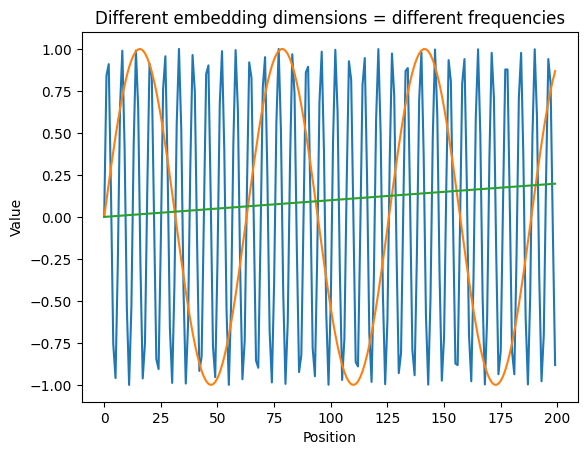

In [14]:
import matplotlib.pyplot as plt

positions = torch.arange(0, 200)
emb = pose(positions)

plt.figure()
plt.plot(positions, emb[:, 0])
plt.plot(positions, emb[:, 2])
plt.plot(positions, emb[:, 6])
plt.title("Different embedding dimensions = different frequencies")
plt.xlabel("Position")
plt.ylabel("Value")
plt.show()


In [15]:
p1=pose(torch.tensor([42]))
p2=pose(torch.tensor([4242]))

In [16]:
torch.norm(p1-p2)

tensor(4.0938)

In [17]:
p3=pose(torch.tensor([43]))
torch.norm(p3-p1)

tensor(1.0147)

Rotary Positional Embedding

In [ ]:
import torch
import math

In [ ]:
def rotangle(lenn,dim):
    pos=torch.arange(lenn).unsqueeze(1)
    dimi=torch.arange(0,dim,2)
    theta=1.0/(10000**(dimi/dim))
    ang=pos*theta
    return ang

In [ ]:
def rope(x,ang):
    xe=x[...,0::2]
    xo=x[...,1::2]
    cos=ang.cos()[None,:,:]
    sin=ang.sin()[None,:,:]
    xre=xe*cos-xo*sin
    xro=xe*sin+xo*cos
    rot=torch.stack((xre,xro),dim=-1)
    rot=rot.flatten(-2)
    return rot